# The disease spread prediction model

# Author: Aknur Mansurkhan

### Dataset source: https://www.kaggle.com/datasets/hopeofchange/climate-driven-disease-spread


1.   Деректерді тазарту: Бос мәндермен (Missing Values) және дубликаттармен жұмыс.
2.   Ауытқуларды өңдеу: Boxplot және IQR әдісі арқылы outliers-ті анықтау.
3.   Визуализация: Matplotlib және Seaborn көмегімен деректердің таралуын және корреляциясын зерттеу.
4.   Feature Engineering: Бар деректерден жаңа пайдалы белгілерді жасау.
5.   Кодтау (Encoding): Санаттық айнымалыларды (sex, island, species) сандық форматқа ауыстыру.
6.   Шкалалау (Scaling): Сандық деректерді бір масштабқа келтіру.





Dataset Description

This synthetic dataset combines climate, environmental, epidemiological, and socio-economic data from 120 countries over 24 years (2000-2023). The aim is to analyze the relationship between climate change, environmental pollution and the spread of infectious diseases (malaria, dengue fever, cholera, Lyme disease). The data is suitable for forecasting tasks, anomaly detection, and risk clustering of regions.



-------------------------------------------------------------------
year - Year of observation


month - Month


country - A country


region - Region (5 categories: North, South, etc.)


avg_temp_c - Average temperature (°C)


precipitation_mm - Precipitation (mm/month)


air_quality_index - Air pollution index (0-500)


uv_index - UV radiation (0-12)


malaria_cases - Reported cases of malaria


dengue_cases - Cases of dengue fever

-------------------------------------------------------------------


In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('climate_disease_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34560 non-null  int64  
 1   month               34560 non-null  int64  
 2   country             34560 non-null  object 
 3   region              34560 non-null  object 
 4   avg_temp_c          34560 non-null  float64
 5   precipitation_mm    34560 non-null  float64
 6   air_quality_index   34560 non-null  float64
 7   uv_index            34560 non-null  float64
 8   malaria_cases       34560 non-null  int64  
 9   dengue_cases        34560 non-null  int64  
 10  population_density  34560 non-null  int64  
 11  healthcare_budget   34560 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 3.2+ MB


In [4]:
df.shape

(34560, 12)

In [6]:
df.describe(include='all')

,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
count,34560.000000,34560.000000,34560,34560,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000
unique,NaN,NaN,120,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Palestinian Territory,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,288,8640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2011.500000,6.500000,NaN,NaN,20.395234,192.667977,43.787766,10.210855,70.519560,75.941464,266.900000,2764.650000
std,6.922287,3.452102,NaN,NaN,8.410940,90.503990,33.079697,1.936540,46.130774,37.323807,136.001073,1418.119148
min,2000.000000,1.000000,NaN,NaN,-2.557056,0.000000,0.000000,0.870704,0.000000,0.000000,50.000000,205.000000
25%,2005.750000,3.750000,NaN,NaN,14.404089,124.641424,15.322767,8.921094,32.000000,48.000000,136.250000,1435.500000
50%,2011.500000,6.500000,NaN,NaN,20.351749,195.315309,40.685931,10.760990,69.000000,76.000000,277.500000,2859.000000
75%,2017.250000,9.250000,NaN,NaN,26.342978,260.147603,68.402041,12.000000,107.000000,104.000000,384.750000,3996.750000


# 1. Handling missing values and duplicates

In [7]:
df.isnull().sum()

,0
year,0
month,0
country,0
region,0
avg_temp_c,0
precipitation_mm,0
air_quality_index,0
uv_index,0
malaria_cases,0
dengue_cases,0


In [9]:
df.duplicated().sum()

np.int64(0)

# So the dataset is clean and there are no duplicates

# 2. Handling outliers

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
num_cols=df.select_dtypes(include='number')

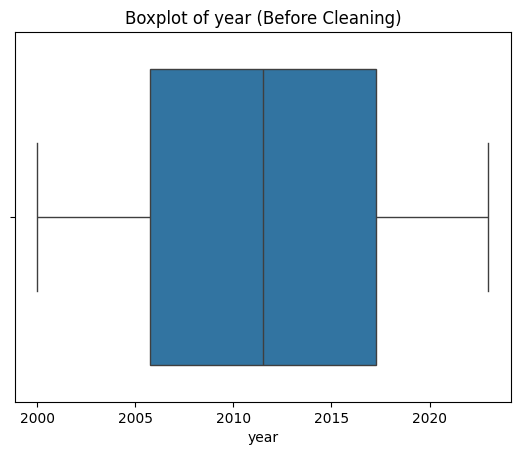

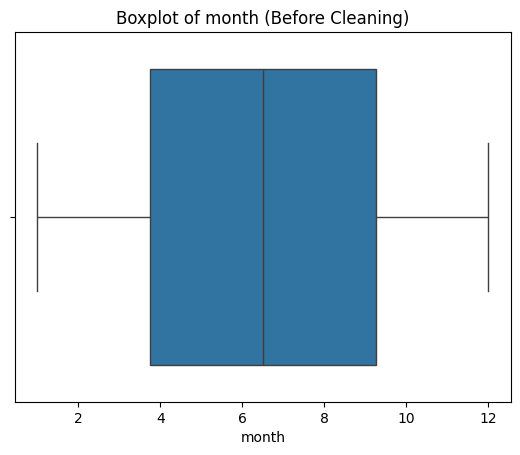

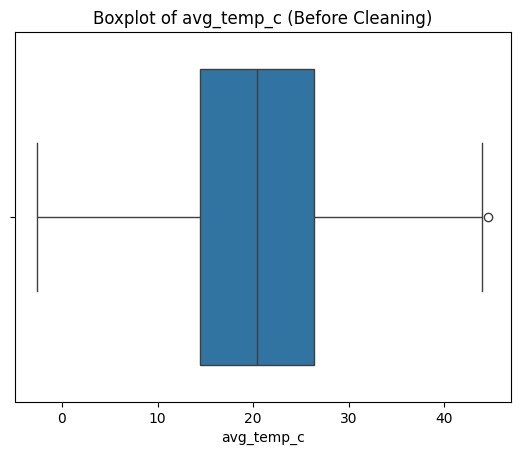

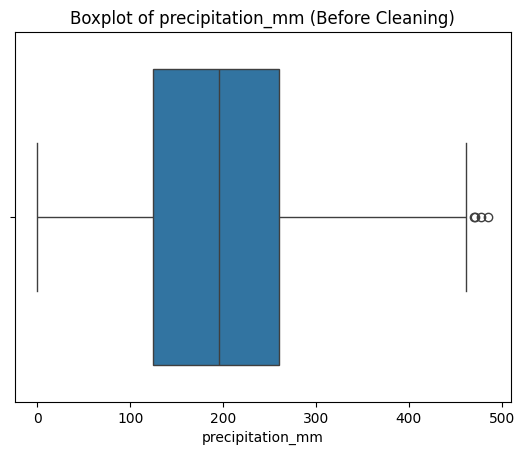

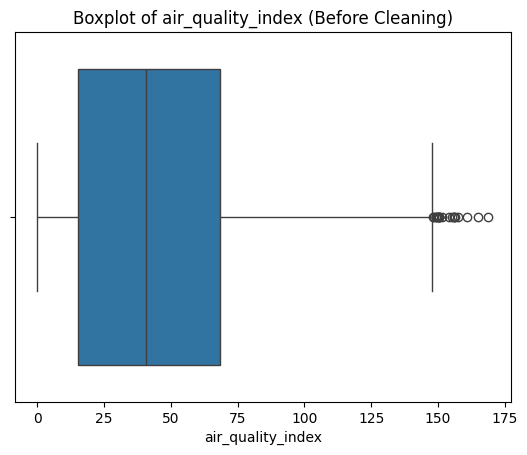

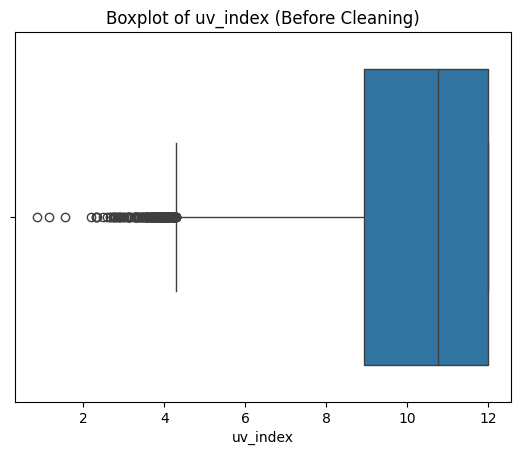

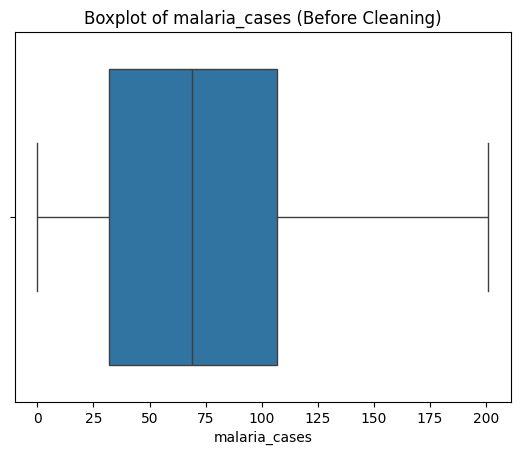

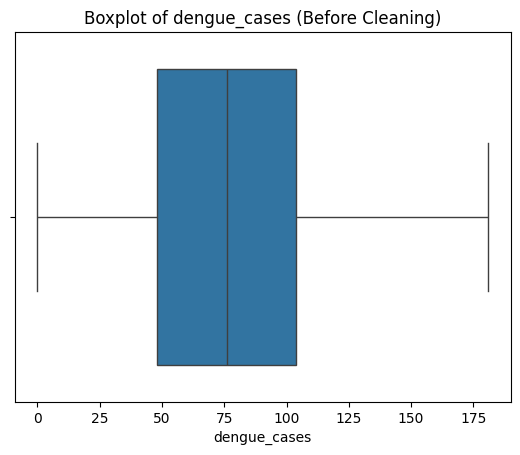

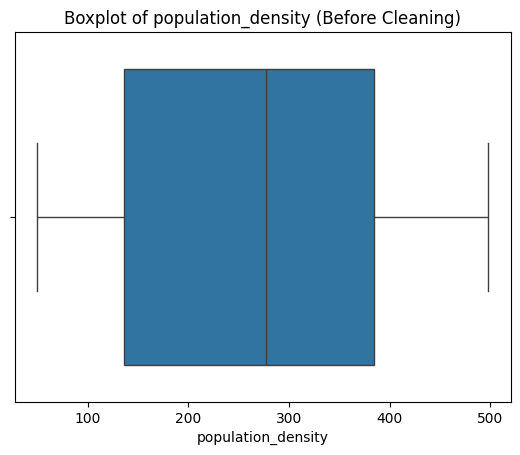

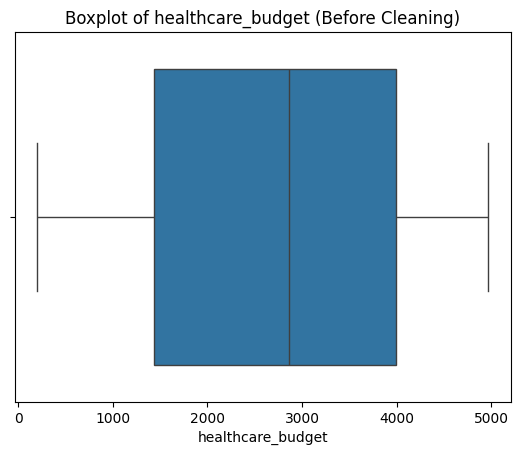

In [20]:
for col in num_cols:
  sns.boxplot(data=df, x=col)
  plt.title(f'Boxplot of {col} (Before Cleaning)')
  plt.show()

`'year' , 'month' , 'avg_temp_c', 'malaria_cases', 'dengue_cases', 'population_density', 'healthcare_budget' are more normalized and dont have outliers`

`But 'precipitation_mm', 'air_quality_index', 'uv_index' columns have outliers.`

### I think the outliers in these columns do not need to be removed

### Instead , we have to handle them with scaling , i guess


# 3.Визуализация: Matplotlib және Seaborn көмегімен деректердің таралуын және корреляциясын зерттеу.

In [22]:
df.columns

Index(['year', 'month', 'country', 'region', 'avg_temp_c', 'precipitation_mm',
       'air_quality_index', 'uv_index', 'malaria_cases', 'dengue_cases',
       'population_density', 'healthcare_budget'],
      dtype='object')

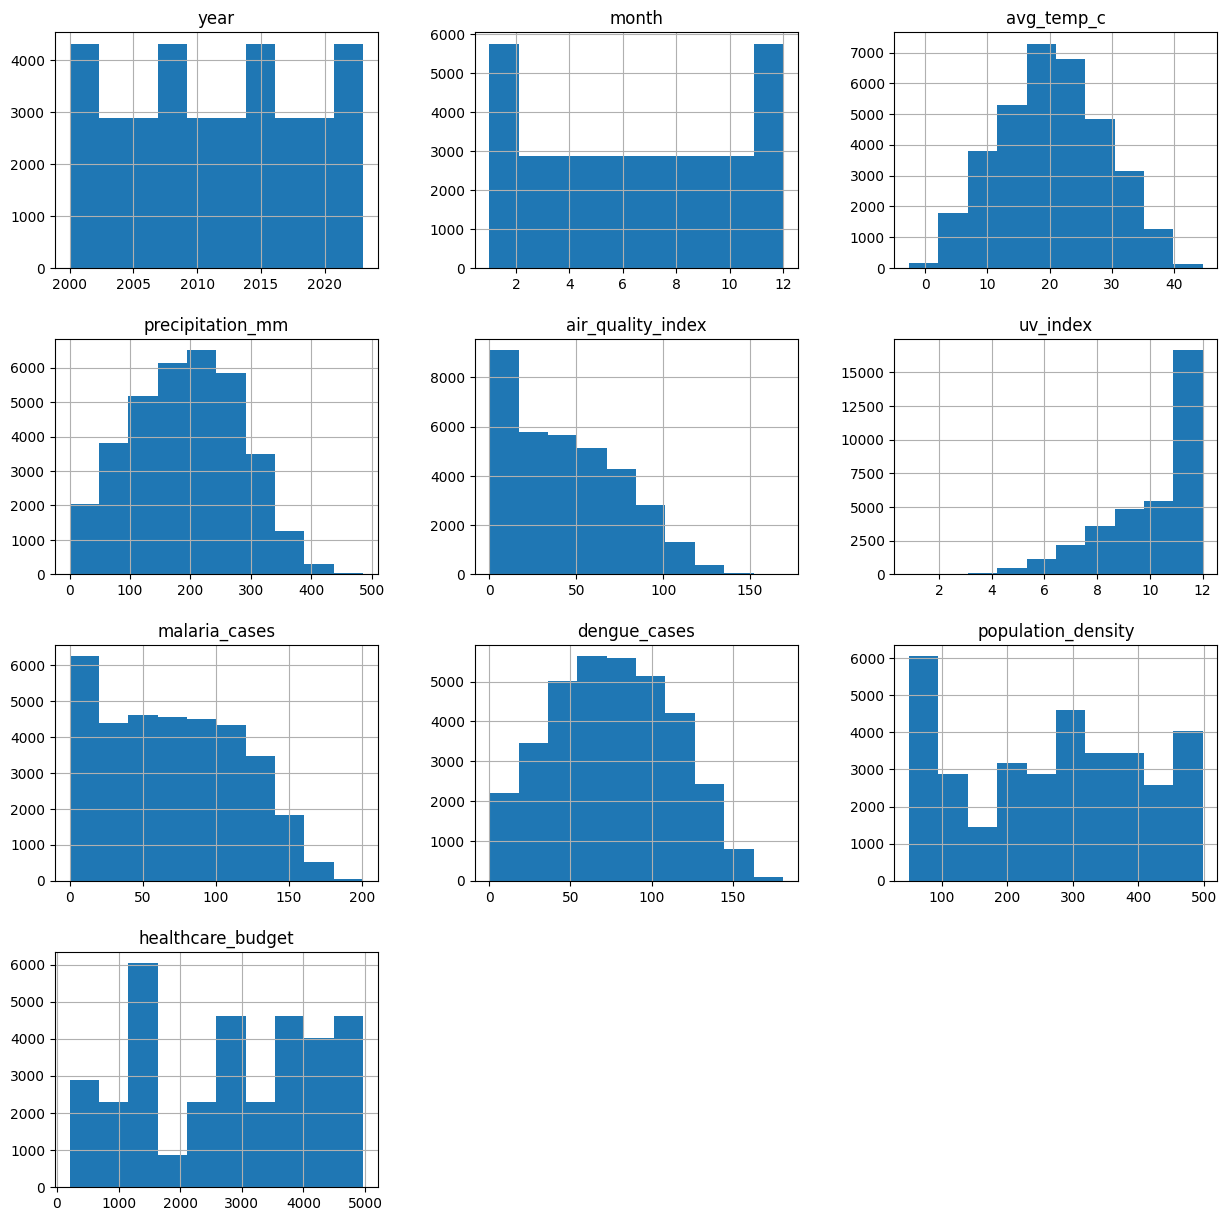

In [23]:
df.hist(figsize=(15,15))
plt.show()

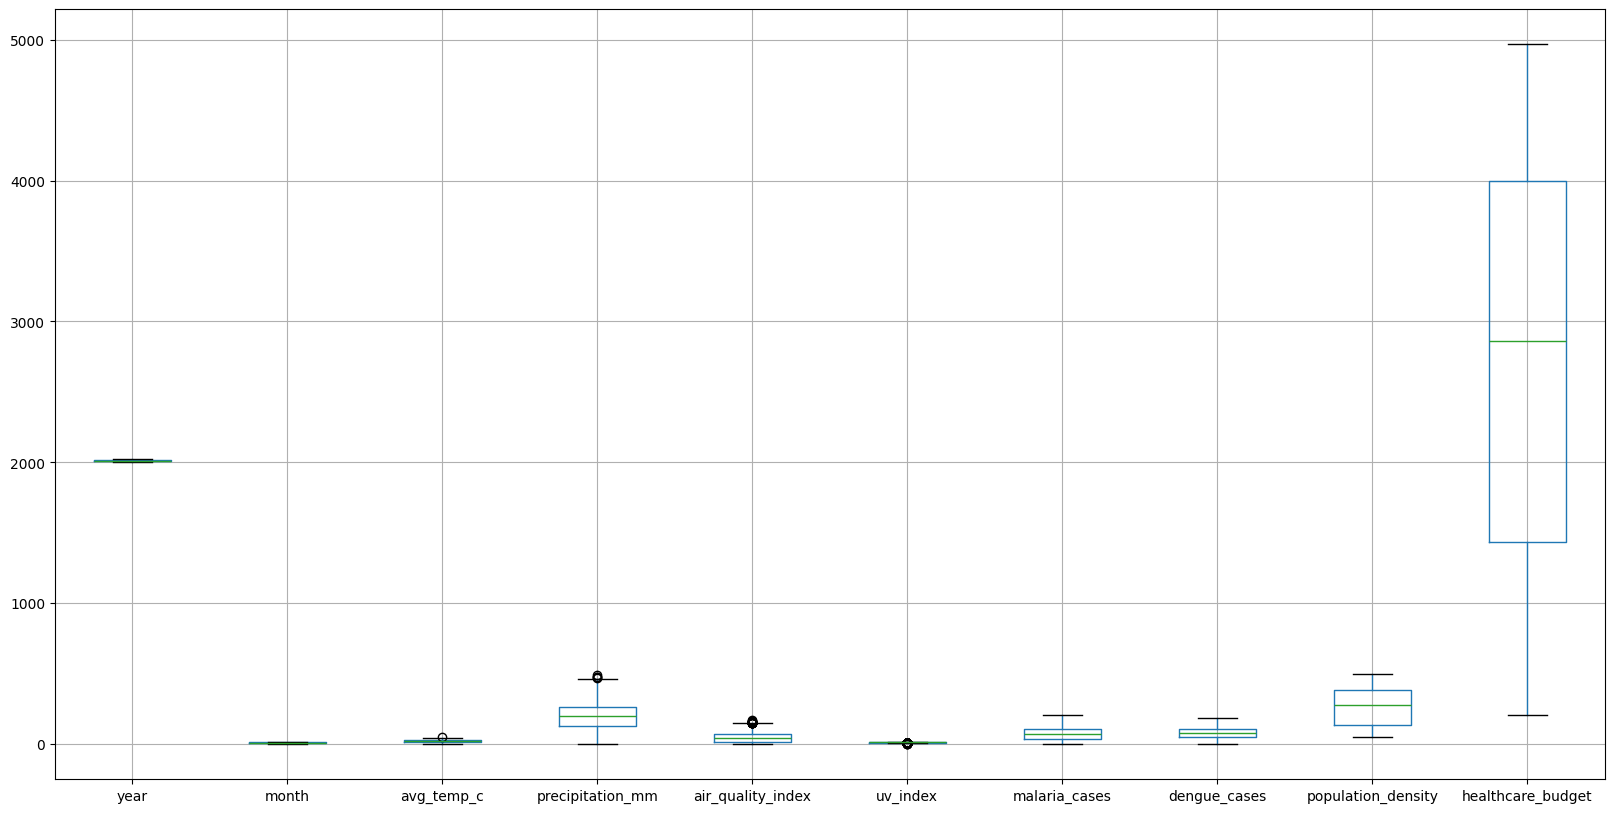

In [26]:
df.boxplot(figsize=(20,10))
plt.show()

In [28]:
numerics=df.select_dtypes(include='number')

In [29]:
correlation=numerics.corr()

In [30]:
correlation

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
year,1.000000e+00,-4.172551e-16,0.082336,-0.003252,-0.275368,-0.004289,0.018529,0.034830,7.955212e-14,1.199888e-13
month,-4.172551e-16,1.000000e+00,-0.513563,0.020827,0.000427,0.011316,-0.128766,-0.228934,8.169150e-16,1.034550e-15
avg_temp_c,8.233597e-02,-5.135628e-01,1.000000,-0.015348,0.036301,0.425900,0.259014,0.451270,-6.155400e-03,-7.491146e-02
precipitation_mm,-3.252118e-03,2.082693e-02,-0.015348,1.000000,0.075877,0.045008,0.285629,0.245269,4.320016e-02,-9.683816e-02
air_quality_index,-2.753680e-01,4.271269e-04,0.036301,0.075877,1.000000,0.065294,0.146599,0.130763,-1.950078e-01,-7.880899e-01
uv_index,-4.289439e-03,1.131601e-02,0.425900,0.045008,0.065294,1.000000,0.132725,0.209896,8.154208e-04,-7.941659e-02
malaria_cases,1.852898e-02,-1.287662e-01,0.259014,0.285629,0.146599,0.132725,1.000000,0.206398,-2.806226e-02,-1.876551e-01
dengue_cases,3.482976e-02,-2.289344e-01,0.451270,0.245269,0.130763,0.209896,0.206398,1.000000,-1.964400e-02,-1.772765e-01
population_density,7.955212e-14,8.169150e-16,-0.006155,0.043200,-0.195008,0.000815,-0.028062,-0.019644,1.000000e+00,2.471803e-01
healthcare_budget,1.199888e-13,1.034550e-15,-0.074911,-0.096838,-0.788090,-0.079417,-0.187655,-0.177277,2.471803e-01,1.000000e+00


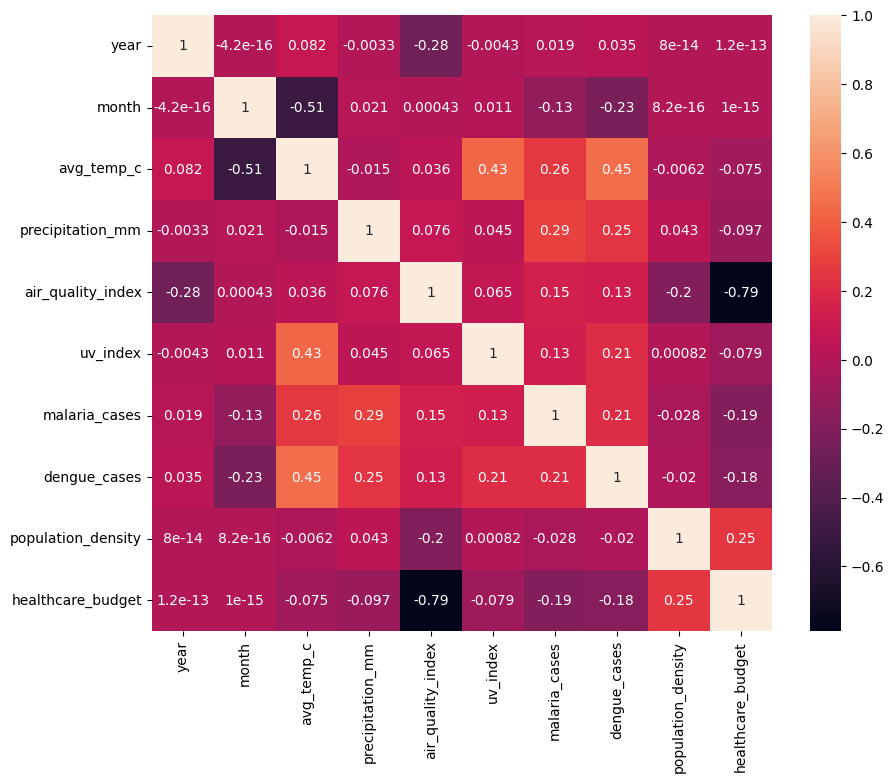

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(data=correlation, annot=True)
plt.show()

# 4.Feature Engineering: Бар деректерден жаңа пайдалы белгілерді жасау.

In [39]:
# 1. Климаттық қатынас белгілері
df["temp_precip_ratio"] = df["avg_temp_c"] / (df["precipitation_mm"] + 1)
df["pollution_uv_ratio"] = df["air_quality_index"] / (df["uv_index"] + 1)

In [40]:
# 2. Ауру ауыртпалығы
df["disease_burden"] = df["malaria_cases"] + df["dengue_cases"]

In [41]:
# 3. Халық санына шаққан ауру
df["cases_per_population"] = df["disease_burden"] / df["population_density"]


In [42]:
# 4. Денсаулық қолдау деңгейі
df["health_support_level"] = df["healthcare_budget"] / df["population_density"]


In [43]:
df.head()

,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget,temp_precip_ratio,pollution_uv_ratio,disease_burden,cases_per_population,health_support_level
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068,0.183772,8.499018,198,1.752212,9.451327
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068,0.256125,6.420610,180,1.592920,9.451327
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068,0.323779,7.161176,114,1.008850,9.451327
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068,0.161539,10.151141,156,1.380531,9.451327
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068,0.139729,5.505439,113,1.000000,9.451327


In [44]:
df.describe()

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget,temp_precip_ratio,pollution_uv_ratio,disease_burden,cases_per_population,health_support_level
count,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000
mean,2011.500000,6.500000,20.395234,192.667977,43.787766,10.210855,70.519560,75.941464,266.900000,2764.650000,0.404245,4.017379,146.461024,0.855055,14.599858
std,6.922287,3.452102,8.410940,90.503990,33.079697,1.936540,46.130774,37.323807,136.001073,1418.119148,2.325958,3.199757,65.052725,0.861194,14.600491
min,2000.000000,1.000000,-2.557056,0.000000,0.000000,0.870704,0.000000,0.000000,50.000000,205.000000,-0.856291,0.000000,0.000000,0.000000,0.516667
25%,2005.750000,3.750000,14.404089,124.641424,15.322767,8.921094,32.000000,48.000000,136.250000,1435.500000,0.067580,1.371565,99.000000,0.337110,6.319816
50%,2011.500000,6.500000,20.351749,195.315309,40.685931,10.760990,69.000000,76.000000,277.500000,2859.000000,0.105924,3.648594,146.000000,0.543409,9.954135
75%,2017.250000,9.250000,26.342978,260.147603,68.402041,12.000000,107.000000,104.000000,384.750000,3996.750000,0.170945,6.115054,192.000000,0.991632,15.206338
max,2023.000000,12.000000,44.583564,485.704079,168.847690,12.000000,201.000000,181.000000,498.000000,4969.000000,41.384897,46.042978,363.000000,6.089286,73.711864


# 5.Кодтау (Encoding): Санаттық айнымалыларды (sex, island, species) сандық форматқа ауыстыру.

In [45]:
from sklearn.preprocessing import OneHotEncoder


In [46]:
cat_cols = ["country", "region"]

In [47]:
encoder = OneHotEncoder(drop="first", sparse_output=False)

In [48]:
encoded = encoder.fit_transform(df[cat_cols])


In [49]:
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))


In [50]:
df_encoded = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
df_encoded

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget,...,country_Turkmenistan,country_Tuvalu,country_United Arab Emirates,country_Uzbekistan,country_Wallis and Futuna,country_Zimbabwe,region_East,region_North,region_South,region_West
0,2000,1,28.132468,152.083870,110.487231,12.000000,53,145,113,1068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000,2,30.886500,119.591418,83.467928,12.000000,132,48,113,1068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000,3,31.366433,95.876124,93.095292,12.000000,34,80,113,1068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000,4,28.481870,175.315731,105.530192,9.395894,23,133,113,1068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2000,5,26.890370,191.445990,60.205979,9.935726,39,74,113,1068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34555,2023,8,13.040751,369.269763,70.218442,12.000000,149,36,52,399,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
34556,2023,9,9.811456,271.028130,74.749481,8.432640,56,47,52,399,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
34557,2023,10,12.308443,228.392496,91.096407,8.034754,104,22,52,399,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
34558,2023,11,20.197689,196.673067,128.859240,12.000000,142,66,52,399,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# 6.Шкалалау (Scaling): Сандық деректерді бір масштабқа келтіру.

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
y = df_encoded["disease_burden"]
X = df_encoded.drop(columns=["disease_burden"])

In [53]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget,...,country_Turkmenistan,country_Tuvalu,country_United Arab Emirates,country_Uzbekistan,country_Wallis and Futuna,country_Zimbabwe,region_East,region_North,region_South,region_West
0,-1.661325,-1.593255,0.919915,-0.448430,2.016356,0.923900,-0.379786,1.850281,-1.131625,-1.196426,...,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.377964,-0.5,-0.5,-0.57735
1,-1.661325,-1.303572,1.247354,-0.807452,1.199550,0.923900,1.332762,-0.748634,-1.131625,-1.196426,...,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.377964,-0.5,-0.5,-0.57735
2,-1.661325,-1.013890,1.304415,-1.069492,1.490589,0.923900,-0.791664,0.108740,-1.131625,-1.196426,...,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.377964,-0.5,-0.5,-0.57735
3,-1.661325,-0.724207,0.961456,-0.191732,1.866502,-0.420840,-1.030120,1.528766,-1.131625,-1.196426,...,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.377964,-0.5,-0.5,-0.57735
4,-1.661325,-0.434524,0.772236,-0.013502,0.496330,-0.142075,-0.683275,-0.052018,-1.131625,-1.196426,...,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.09167,-0.377964,-0.5,-0.5,-0.57735


In [54]:
X_scaled.shape

(34560, 137)

# 7. ML Модель — Disease Spread Prediction

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [57]:
model = RandomForestRegressor(n_estimators=300,random_state=42)

In [58]:
model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=300, random_state=42)

In [61]:
y_pred = model.predict(X_test)
y_pred

array([123.75666667, 172.09333333, 120.08      , ..., 163.72666667,
       215.02666667, 175.80666667])

In [60]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² score:", r2_score(y_test, y_pred))

MSE: 0.39512914576903324
RMSE: 0.6285929889594961
R² score: 0.9999084387522716


#